In [1]:
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting(use_latex='mathjax')

In [2]:
class ReferenceFrame(me.ReferenceFrame):

    def __init__(self, *args, **kwargs):

        kwargs.pop('latexs', None)

        lab = args[0].lower()
        tex = r'\hat{{{}}}_{}'

        super(ReferenceFrame, self).__init__(*args,
                                             latexs=(tex.format(lab, 'x'),
                                                     tex.format(lab, 'y'),
                                                     tex.format(lab, 'z')),
                                             **kwargs)
me.ReferenceFrame = ReferenceFrame

In [3]:
import numpy as np

In [4]:
a, b, c, d = sm.symbols('a, b, c, d')

mat = np.array([[a, b], [c, d]])
mat

array([[a, b],
       [c, d]], dtype=object)

In [5]:
sym_mat = sm.Matrix([[a, b], [c, d]])
eval_sym_mat = sm.lambdify((a, b, c, d), sym_mat)
num_mat = eval_sym_mat(1.0, 2.0, 3.0, 4.0)
num_mat

array([[1., 2.],
       [3., 4.]])

In [6]:
np.cos(5) + sm.cos(5)

0.283662185463226 + cos(5)

In [7]:
m, g, kt, kl, l = sm.symbols('m, g, k_t, k_l, l')
q1, q2, q3 = me.dynamicsymbols('q1, q2, q3')
u1, u2, u3 = me.dynamicsymbols('u1, u2, u3')

N = me.ReferenceFrame('N')
A = me.ReferenceFrame('A')
B = me.ReferenceFrame('B')

A.orient_axis(N, q1, N.z)
B.orient_axis(A, q2, A.x)

A.set_ang_vel(N, u1*N.z)
B.set_ang_vel(A, u2*A.x)

O = me.Point('O')
Ao = me.Point('A_O')
Bo = me.Point('B_O')
Q = me.Point('Q')

Ao.set_pos(O, l/2*A.x)
Bo.set_pos(O, l*A.x)
Q.set_pos(Bo, q3*B.y)

O.set_vel(N, 0)
Ao.v2pt_theory(O, N, A)
Bo.v2pt_theory(O, N, A)
Q.set_vel(B, u3*B.y)
Q.v1pt_theory(Bo, N, B)

t = me.dynamicsymbols._t

qdot_repl = {q1.diff(t): u1,
             q2.diff(t): u2,
             q3.diff(t): u3}

Q.set_acc(N, Q.acc(N).xreplace(qdot_repl))

R_Ao = m*g*N.x
R_Bo = m*g*N.x + kl*q3*B.y
R_Q = m/4*g*N.x - kl*q3*B.y
T_A = -kt*q1*N.z + kt*q2*A.x
T_B = -kt*q2*A.x

I = m*l**2/12
I_A_Ao = I*me.outer(A.y, A.y) + I*me.outer(A.z, A.z)
I_B_Bo = I*me.outer(B.x, B.x) + I*me.outer(B.z, B.z)

points = [Ao, Bo, Q]
forces = [R_Ao, R_Bo, R_Q]
masses = [m, m, m/4]

frames = [A, B]
torques = [T_A, T_B]
inertias = [I_A_Ao, I_B_Bo]

Fr_bar = []
Frs_bar = []

for ur in [u1, u2, u3]:

    Fr = 0
    Frs = 0

    for Pi, Ri, mi in zip(points, forces, masses):
        vr = Pi.vel(N).diff(ur, N)
        Fr += vr.dot(Ri)
        Rs = -mi*Pi.acc(N)
        Frs += vr.dot(Rs)

    for Bi, Ti, Ii in zip(frames, torques, inertias):
        wr = Bi.ang_vel_in(N).diff(ur, N)
        Fr += wr.dot(Ti)
        Ts = -(Bi.ang_acc_in(N).dot(Ii) +
               me.cross(Bi.ang_vel_in(N), Ii).dot(Bi.ang_vel_in(N)))
        Frs += wr.dot(Ts)

    Fr_bar.append(Fr)
    Frs_bar.append(Frs)

Fr = sm.Matrix(Fr_bar)
Frs = sm.Matrix(Frs_bar)

q = sm.Matrix([q1, q2, q3])
u = sm.Matrix([u1, u2, u3])

qd = q.diff(t)
ud = u.diff(t)

ud_zerod = {udr: 0 for udr in ud}

Mk = -sm.eye(3)
gk = u

Md = Frs.jacobian(ud)
gd = Frs.xreplace(ud_zerod) + Fr

In [8]:
q, u, qd, ud

⎛⎡q₁⎤  ⎡u₁⎤  ⎡q₁̇⎤  ⎡u₁̇⎤⎞
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢q₂⎥, ⎢u₂⎥, ⎢q₂̇⎥, ⎢u₂̇⎥⎟
⎜⎢  ⎥  ⎢  ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎝⎣q₃⎦  ⎣u₃⎦  ⎣q₃̇⎦  ⎣u₃̇⎦⎠

In [9]:
Mk, gk

⎛⎡-1  0   0 ⎤  ⎡u₁⎤⎞
⎜⎢          ⎥  ⎢  ⎥⎟
⎜⎢0   -1  0 ⎥, ⎢u₂⎥⎟
⎜⎢          ⎥  ⎢  ⎥⎟
⎝⎣0   0   -1⎦  ⎣u₃⎦⎠

In [10]:
me.find_dynamicsymbols(Mk), me.find_dynamicsymbols(gk)

(set(), {u₁, u₂, u₃})

In [11]:
Md, gd

⎛                                                                              ↪
⎜⎡   2      2           2         2    2                                   ⎤   ↪
⎜⎢  l ⋅m⋅cos (q₂)   19⋅l ⋅m   m⋅q₃ ⋅cos (q₂)  l⋅m⋅q₃⋅sin(q₂)  -l⋅m⋅cos(q₂) ⎥   ↪
⎜⎢- ───────────── - ─────── - ──────────────  ──────────────  ─────────────⎥   ↪
⎜⎢       12           12            4               4               4      ⎥   ↪
⎜⎢                                                                         ⎥   ↪
⎜⎢                                               2         2               ⎥   ↪
⎜⎢              l⋅m⋅q₃⋅sin(q₂)                  l ⋅m   m⋅q₃                ⎥,  ↪
⎜⎢              ──────────────                - ──── - ─────        0      ⎥   ↪
⎜⎢                    4                          12      4                 ⎥   ↪
⎜⎢                                                                         ⎥   ↪
⎜⎢              -l⋅m⋅cos(q₂)                                       -m      ⎥   ↪
⎜⎢              ────────────

In [12]:
me.find_dynamicsymbols(Md), me.find_dynamicsymbols(gd)

({q₂, q₃}, {q₁, q₂, q₃, u₁, u₂, u₃})

In [13]:
Mk.free_symbols | gk.free_symbols | Md.free_symbols | gd.free_symbols

{g, kₗ, kₜ, l, m, t}

In [14]:
p = sm.Matrix([g, kl, kt, l, m])
p

⎡g ⎤
⎢  ⎥
⎢kₗ⎥
⎢  ⎥
⎢kₜ⎥
⎢  ⎥
⎢l ⎥
⎢  ⎥
⎣m ⎦

In [15]:
eval_eom = sm.lambdify((q, u, p), [Mk, gk, Md, gd])

In [16]:
q_vals = np.array([
    np.deg2rad(0.0),  # q1, rad
    np.deg2rad(0.0),  # q2, rad
    0.0,  # q3, m
])
q_vals, type(q_vals), q_vals.shape

(array([0., 0., 0.]), numpy.ndarray, (3,))

In [17]:
u_vals = np.array([
    0.0,  # u1, rad/s
    0.0,  # u2, rad/s
    0.05,  # u3, m/s
])
u_vals, type(u_vals), u_vals.shape

(array([0.  , 0.  , 0.05]), numpy.ndarray, (3,))

In [18]:
p_vals = np.array([
    9.81,  # g, m/s**2
    10.0,  # kl, N/m
    10.0,  # kt, Nm/rad
    0.6,  # l, m
    1.0,  # m, kg
])
p_vals, type(p_vals), p_vals.shape

(array([ 9.81, 10.  , 10.  ,  0.6 ,  1.  ]), numpy.ndarray, (5,))

In [19]:
Mk_vals, gk_vals, Md_vals, gd_vals = eval_eom(q_vals, u_vals, p_vals)
Mk_vals, gk_vals, Md_vals, gd_vals

(array([[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1]]),
 array([[0.  ],
        [0.  ],
        [0.05]]),
 array([[-0.6 ,  0.  , -0.15],
        [ 0.  , -0.03,  0.  ],
        [-0.15,  0.  , -0.25]]),
 array([[0.],
        [0.],
        [0.]]))

In [20]:
qd_vals = np.linalg.solve(-Mk_vals, np.squeeze(gk_vals))
qd_vals

array([0.  , 0.  , 0.05])

In [21]:
ud_vals = np.linalg.solve(-Md_vals, np.squeeze(gd_vals))
ud_vals

array([0., 0., 0.])

In [22]:
np.linalg.solve(-Mk_vals, gk_vals)

array([[0.  ],
       [0.  ],
       [0.05]])

In [23]:
def euler_integrate(rhs_func, t0, tf, m, x0_vals, p_vals):
    """Returns state trajectory and corresponding values of time resulting
    from integrating the ordinary differential equations with Euler's
    Method.

    Parameters
    ==========
    rhs_func : function
       Python function that evaluates the derivative of the state and takes
       this form ``dxdt = f(t, x, p)``.
    t0 : float
      Initial value of time.
    tf : float
      Final value of time.
    m : integer
      Number of time values.
    x0_vals : array_like, shape(2*n,)
       Values of the state x at t0.
    p_vals : array_like, shape(o,)
       Values of constant parameters.

    Returns
    =======
    t : ndarray, shape(m,)
       Monotonically increasing array of time values.
    x : ndarray(m, 2*n)
       State values at each time in t.

    """
    # create an array of time values.
    t = np.linspace(t0, tf, num=m)

    # create an empty array to hold the state values.
    x = np.empty((len(t), len(x0_vals)))

    # set the initial conditions to the first element.
    x[0, :] = x0_vals

    # use a for loop to sequentially calculate each new x.
    for i, ti in enumerate(t[:-1]):
        delt = t[i + 1] - ti
        x[i + 1, :] = x[i, :] + delt*rhs_func(ti, x[i, :], p_vals)

    return t, x

In [24]:
def eval_rhs(t, x, p):
    """Return the right hand side of the explicit ordinary differential
    equations which evaluates the time derivative of the state ``x`` at time
    ``t``.

    Parameters
    ==========
    t : float
       Time in seconds.
    x : array_like, shape(6,)
       State at time t: [q1, q2, q3, u1, u2, u3]
    p : array_like, shape(5,)
       Constant parameters: [g, kl, kt, l, m]

    Returns
    =======
    xd : ndarray, shape(6,)
        Derivative of the state with respect to time at time ``t``.

    """

    # unpack the q and u vectors from x
    q = x[:3]
    u = x[3:]

    # evaluate the equations of motion matrices with the values of q, u, p
    Mk, gk, Md, gd = eval_eom(q, u, p)

    # solve for q' and u'
    qd = np.linalg.solve(-Mk, np.squeeze(gk))
    ud = np.linalg.solve(-Md, np.squeeze(gd))

    # pack dq/dt and du/dt into a new state time derivative vector dx/dt
    xd = np.empty_like(x)
    xd[:3] = qd
    xd[3:] = ud

    return xd

In [25]:
x0 = np.empty(6)
x0[:3] = q_vals
x0[3:] = u_vals
t0 = 0.1
t0, x0

(0.1, array([0.  , 0.  , 0.  , 0.  , 0.  , 0.05]))

In [26]:
eval_rhs(t0, x0, p_vals)

array([0.  , 0.  , 0.05, 0.  , 0.  , 0.  ])

In [27]:
tf = 10.0
ts, xs = euler_integrate(eval_rhs, t0, tf, 255, x0, p_vals)

In [28]:
ts

array([ 0.1       ,  0.13897638,  0.17795276,  0.21692913,  0.25590551,
        0.29488189,  0.33385827,  0.37283465,  0.41181102,  0.4507874 ,
        0.48976378,  0.52874016,  0.56771654,  0.60669291,  0.64566929,
        0.68464567,  0.72362205,  0.76259843,  0.8015748 ,  0.84055118,
        0.87952756,  0.91850394,  0.95748031,  0.99645669,  1.03543307,
        1.07440945,  1.11338583,  1.1523622 ,  1.19133858,  1.23031496,
        1.26929134,  1.30826772,  1.34724409,  1.38622047,  1.42519685,
        1.46417323,  1.50314961,  1.54212598,  1.58110236,  1.62007874,
        1.65905512,  1.6980315 ,  1.73700787,  1.77598425,  1.81496063,
        1.85393701,  1.89291339,  1.93188976,  1.97086614,  2.00984252,
        2.0488189 ,  2.08779528,  2.12677165,  2.16574803,  2.20472441,
        2.24370079,  2.28267717,  2.32165354,  2.36062992,  2.3996063 ,
        2.43858268,  2.47755906,  2.51653543,  2.55551181,  2.59448819,
        2.63346457,  2.67244094,  2.71141732,  2.7503937 ,  2.78

In [29]:
type(ts), ts.shape

(numpy.ndarray, (255,))

In [30]:
xs

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  5.00000000e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.94881890e-03,
         0.00000000e+00,  0.00000000e+00,  5.00000000e-02],
       [ 0.00000000e+00,  0.00000000e+00,  3.89763780e-03,
         5.28353246e-04,  0.00000000e+00,  4.66446720e-02],
       ...,
       [-4.64851382e-02,  0.00000000e+00,  1.52374707e+02,
         4.10999960e-02,  0.00000000e+00,  1.74734981e+02],
       [-4.48832092e-02,  0.00000000e+00,  1.59185244e+02,
         4.10640199e-02,  0.00000000e+00, -6.27977646e+01],
       [-4.32826825e-02,  0.00000000e+00,  1.56737615e+02,
         4.58082172e-02,  0.00000000e+00, -3.10951562e+02]],
      shape=(255, 6))

In [31]:
type(xs), xs.shape

(numpy.ndarray, (255, 6))

In [32]:
import matplotlib.pyplot as plt

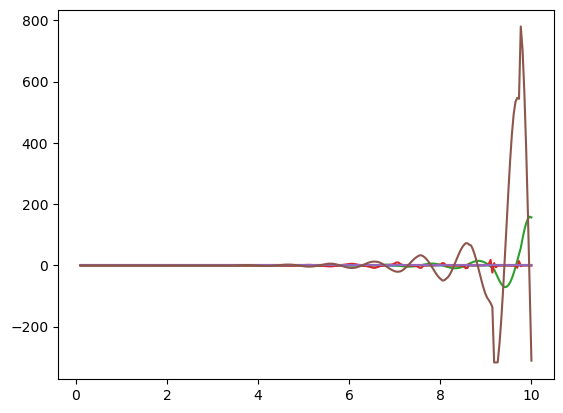

In [33]:
plt.plot(ts, xs);

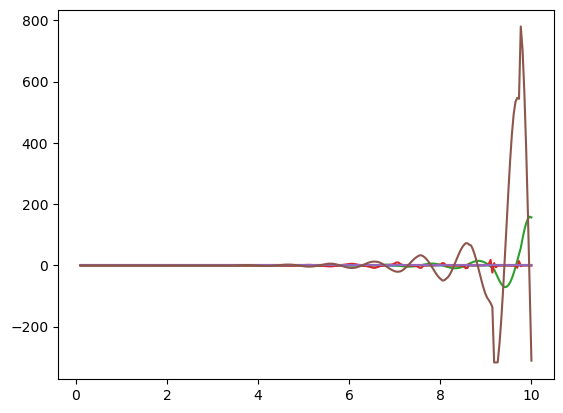

In [34]:
plt.plot(ts, xs)

In [35]:
def plot_results(ts, xs):
    """Returns the array of axes of a 4 panel plot of the state trajectory
    versus time.

    Parameters
    ==========
    ts : array_like, shape(m,)
       Values of time.
    xs : array_like, shape(m, 6)
       Values of the state trajectories corresponding to ``ts`` in order
       [q1, q2, q3, u1, u2, u3].

    Returns
    =======
    axes : ndarray, shape(4,)
       Matplotlib axes for each panel.

    """

    fig, axes = plt.subplots(4, 1, sharex=True)

    fig.set_size_inches((10.0, 6.0))

    axes[0].plot(ts, np.rad2deg(xs[:, :2]))
    axes[1].plot(ts, xs[:, 2])
    axes[2].plot(ts, np.rad2deg(xs[:, 3:5]))
    axes[3].plot(ts, xs[:, 5])

    axes[0].legend([me.vlatex(q[0], mode='inline'),
                    me.vlatex(q[1], mode='inline')])
    axes[1].legend([me.vlatex(q[2], mode='inline')])
    axes[2].legend([me.vlatex(u[0], mode='inline'),
                    me.vlatex(u[1], mode='inline')])
    axes[3].legend([me.vlatex(u[2], mode='inline')])

    axes[0].set_ylabel('Angle [deg]')
    axes[1].set_ylabel('Distance [m]')
    axes[2].set_ylabel('Angular Rate [deg/s]')
    axes[3].set_ylabel('Speed [m/s]')

    axes[3].set_xlabel('Time [s]')

    fig.tight_layout()

    return axes

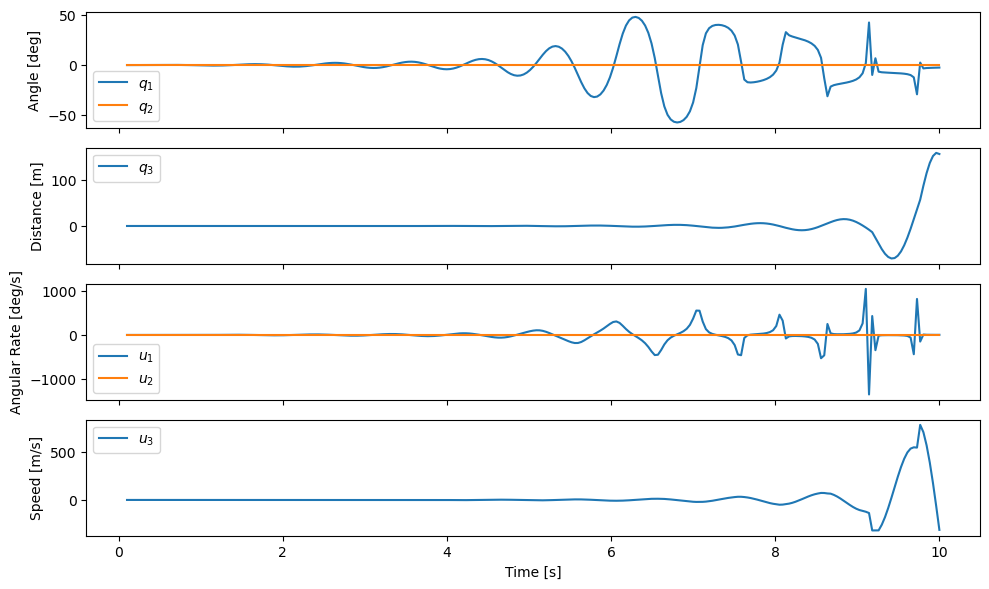

In [36]:
plot_results(ts, xs);

In [37]:
from scipy.integrate import solve_ivp

In [38]:
result = solve_ivp(eval_rhs, (t0, tf), x0, args=(p_vals,))

In [39]:
result.t

array([ 0.1       ,  0.11960784,  0.24400406,  0.38580127,  0.53185406,
        0.67306043,  0.82279598,  0.97891102,  1.12892957,  1.27859048,
        1.43289821,  1.57940582,  1.7264164 ,  1.87297926,  2.01532091,
        2.15703327,  2.2917162 ,  2.43504216,  2.58173672,  2.72973891,
        2.87706506,  3.03084224,  3.18501274,  3.32910133,  3.48593214,
        3.63714375,  3.77740903,  3.92712842,  4.05323645,  4.17934447,
        4.30497749,  4.45308646,  4.59245103,  4.73817861,  4.89595636,
        5.042981  ,  5.19738241,  5.35243045,  5.49549195,  5.64643247,
        5.79416614,  5.93300916,  6.07472577,  6.21980601,  6.36129162,
        6.50433503,  6.65365854,  6.79845728,  6.94960429,  7.10224558,
        7.25242423,  7.40434715,  7.55569177,  7.70615237,  7.84747343,
        7.98422811,  8.09538012,  8.20653213,  8.35190192,  8.49604492,
        8.63720642,  8.78904735,  8.94403313,  9.09484022,  9.24371831,
        9.39703471,  9.54450531,  9.68955065,  9.83512521,  9.97

In [40]:
result.y

array([[ 0.00000000e+00,  4.36297564e-07,  1.58863039e-04,
         9.56286800e-04,  1.98319957e-03,  1.88444389e-03,
        -1.47669197e-04, -3.03774013e-03, -3.87155799e-03,
        -1.38796233e-03,  2.92733014e-03,  5.17281498e-03,
         3.38458889e-03, -1.27571106e-03, -5.04381772e-03,
        -5.10334039e-03, -1.66136832e-03,  3.00163531e-03,
         5.19801802e-03,  3.27399178e-03, -8.48271710e-04,
        -3.78079176e-03, -3.23205321e-03, -6.09490964e-04,
         1.77546925e-03,  2.04310914e-03,  1.06231075e-03,
         1.52420908e-04, -3.24037037e-05, -8.41195570e-05,
        -5.57789841e-04, -1.62811309e-03, -2.10049466e-03,
        -8.77195232e-04,  2.01275969e-03,  3.88592131e-03,
         2.68552281e-03, -1.36197062e-03, -4.66440300e-03,
        -4.54274961e-03, -5.99946747e-04,  3.82286442e-03,
         5.60749074e-03,  3.16635584e-03, -1.49899841e-03,
        -4.87756633e-03, -4.38124837e-03, -7.18389897e-04,
         3.06879962e-03,  3.86563464e-03,  1.66101611e-0

In [41]:
np.shape(result.y)

(6, 71)

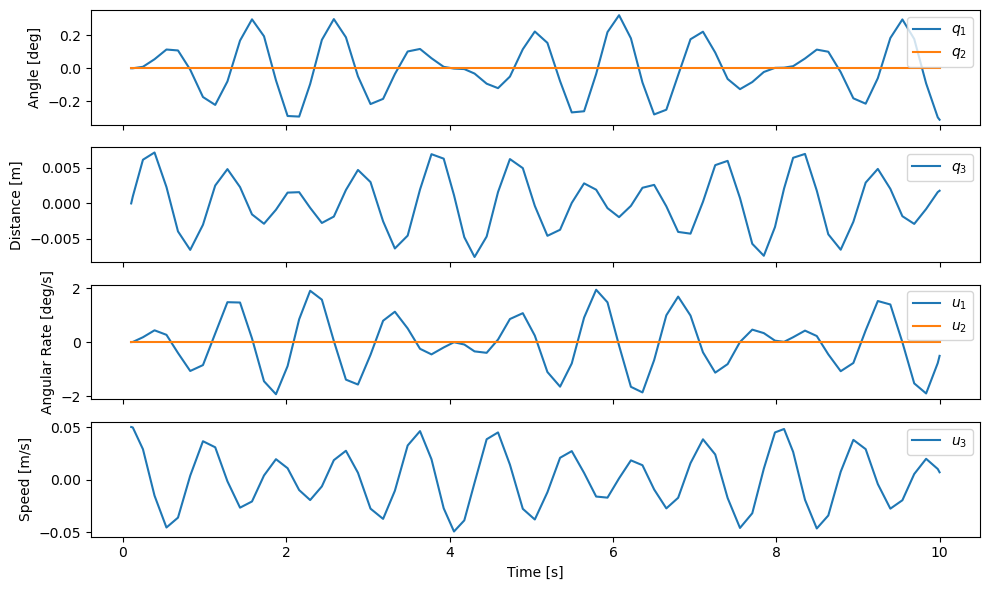

In [42]:
plot_results(result.t, np.transpose(result.y));

In [43]:
result = solve_ivp(eval_rhs, (t0, tf), x0, args=(p_vals,), t_eval=ts)

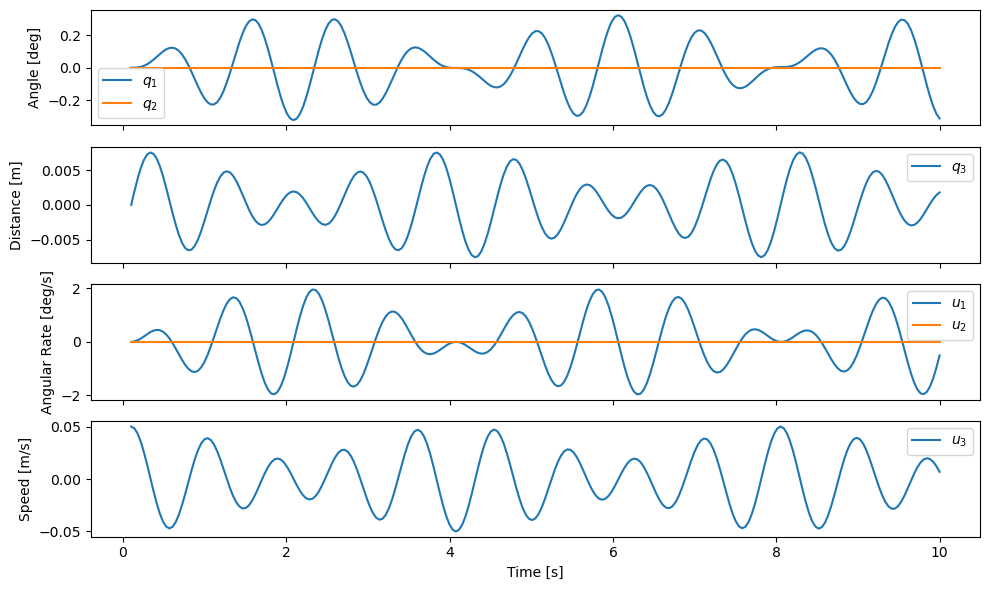

In [44]:
plot_results(result.t, np.transpose(result.y));

In [45]:
np.rad2deg(xs[:, 0] - np.transpose(result.y)[:, 0])

array([ 0.00000000e+00, -1.90156111e-04, -1.52010147e-03, -3.83139913e-03,
       -6.65934070e-03, -9.30761469e-03, -1.10275517e-02, -1.09665957e-02,
       -8.26929692e-03, -2.39366001e-03,  6.82948932e-03,  1.92060486e-02,
        3.41046209e-02,  5.03250916e-02,  6.62427931e-02,  7.98617783e-02,
        8.89908096e-02,  9.15919595e-02,  8.58166000e-02,  7.01690958e-02,
        4.39690582e-02,  7.52169235e-03, -3.78660069e-02, -8.99737534e-02,
       -1.45416463e-01, -2.00016591e-01, -2.48902539e-01, -2.86901933e-01,
       -3.09021269e-01, -3.10982238e-01, -2.89406619e-01, -2.42250228e-01,
       -1.69488899e-01, -7.31833239e-02,  4.25245549e-02,  1.71523229e-01,
        3.05716943e-01,  4.35675760e-01,  5.51050766e-01,  6.41373208e-01,
        6.97056204e-01,  7.10024544e-01,  6.74325164e-01,  5.87108115e-01,
        4.49213817e-01,  2.65307685e-01,  4.37738775e-02, -2.03238110e-01,
       -4.60579798e-01, -7.10796406e-01, -9.35321537e-01, -1.11588296e+00,
       -1.23580584e+00, -

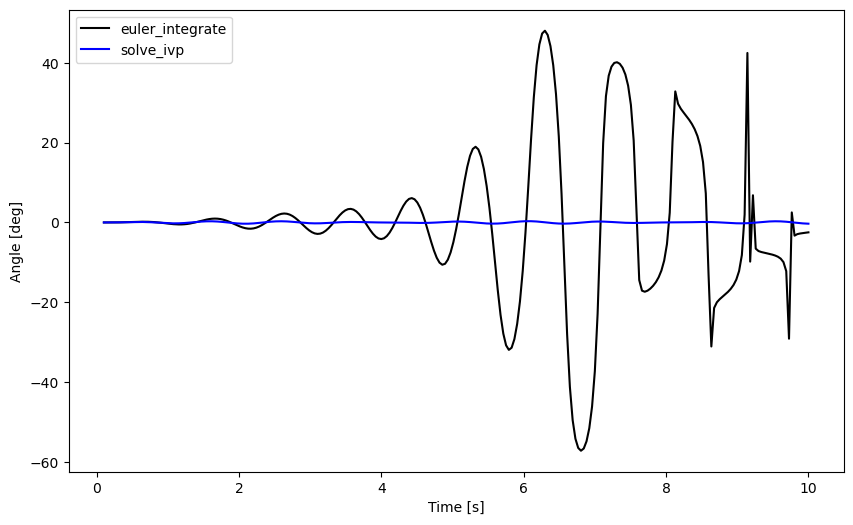

In [46]:
fig, ax = plt.subplots()
fig.set_size_inches((10.0, 6.0))

ax.plot(ts, np.rad2deg(xs[:, 0]), 'k',
        result.t, np.rad2deg(np.transpose(result.y)[:, 0]), 'b');
ax.legend(['euler_integrate', 'solve_ivp'])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Angle [deg]');

In [47]:
xs = np.transpose(result.y)

In [48]:
M = me.ReferenceFrame('M')
M.orient_axis(N, sm.pi/2, N.z)

In [49]:
Bl = me.Point('B_l')
Br = me.Point('B_r')
Bl.set_pos(Bo, -l/2*B.y)
Br.set_pos(Bo, l/2*B.y)

In [50]:
coordinates = O.pos_from(O).to_matrix(M)
for point in [Bo, Q, Bl, Br]:
    coordinates = coordinates.row_join(point.pos_from(O).to_matrix(M))

eval_point_coords = sm.lambdify((q, p), coordinates)
eval_point_coords(q_vals, p_vals)

array([[ 0. ,  0. ,  0. , -0.3,  0.3],
       [ 0. , -0.6, -0.6, -0.6, -0.6],
       [ 0. ,  0. ,  0. , -0. ,  0. ]])

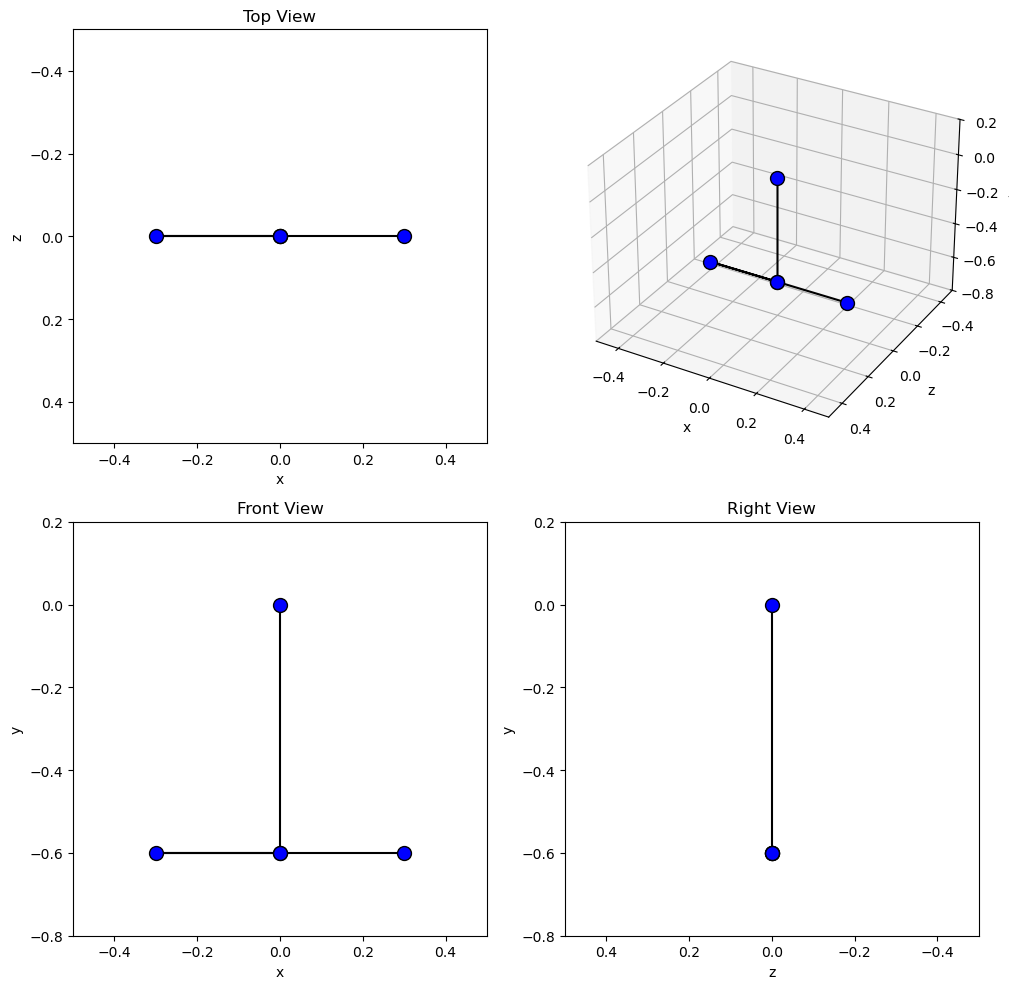

In [51]:
# initial configuration of the points
x, y, z = eval_point_coords(q_vals, p_vals)

# create a figure
fig = plt.figure()
fig.set_size_inches((10.0, 10.0))

# setup the subplots
ax_top = fig.add_subplot(2, 2, 1)
ax_3d = fig.add_subplot(2, 2, 2, projection='3d')
ax_front = fig.add_subplot(2, 2, 3)
ax_right = fig.add_subplot(2, 2, 4)

# common line and marker properties for each panel
line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'blue',
    'markersize': 10,
}

# top view
lines_top, = ax_top.plot(x, z, **line_prop)
ax_top.set_xlim((-0.5, 0.5))
ax_top.set_ylim((0.5, -0.5))
ax_top.set_title('Top View')
ax_top.set_xlabel('x')
ax_top.set_ylabel('z')
ax_top.set_aspect('equal')

# 3d view
lines_3d, = ax_3d.plot(x, z, y, **line_prop)
ax_3d.set_xlim((-0.5, 0.5))
ax_3d.set_ylim((0.5, -0.5))
ax_3d.set_zlim((-0.8, 0.2))
ax_3d.set_xlabel('x')
ax_3d.set_ylabel('z')
ax_3d.set_zlabel('y')

# front view
lines_front, = ax_front.plot(x, y, **line_prop)
ax_front.set_xlim((-0.5, 0.5))
ax_front.set_ylim((-0.8, 0.2))
ax_front.set_title('Front View')
ax_front.set_xlabel('x')
ax_front.set_ylabel('y')
ax_front.set_aspect('equal')

# right view
lines_right, = ax_right.plot(z, y, **line_prop)
ax_right.set_xlim((0.5, -0.5))
ax_right.set_ylim((-0.8, 0.2))
ax_right.set_title('Right View')
ax_right.set_xlabel('z')
ax_right.set_ylabel('y')
ax_right.set_aspect('equal')

fig.tight_layout()

In [52]:
from matplotlib.animation import FuncAnimation

In [53]:
def animate(i):
    x, y, z = eval_point_coords(xs[i, :3], p_vals)
    lines_top.set_data(x, z)
    lines_3d.set_data_3d(x, z, y)
    lines_front.set_data(x, y)
    lines_right.set_data(z, y)

In [54]:
ani = FuncAnimation(fig, animate, len(ts))

In [55]:
# from IPython.display import HTML

# HTML(ani.to_jshtml(fps=30))